<a href="https://colab.research.google.com/github/TejasDharmale/complex-adaptive-systems/blob/main/CAS_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2.1 - Simulating dynamical systems in Jax

    Name: Tejas Dharmale
    Student #: s1190137

In [1]:
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr
from jax.random import PRNGKey

# Exercise 1: Analytical solution of linear systems (3 points)
For linear systems $\dot{x} = A x$, we can often analytically compute the solution.

A) Using separation of variables, write down an analytical solution of the ordinary differential equation
$$\dfrac{dx}{dt} = \lambda x.$$
Make sure to express the solution with the initial condition.

B) Using this solution, plot the dynamics of the system over time given an initial condition and value of $\lambda$.

## Solution 1:


YOUR ANSWER HERE

**Question 1A) Separation of variables**

We start from:
$$\frac{dx}{dt} = \lambda x.$$

Separate the variables so that all $x$ terms are on one side and all $t$ terms on the other:
$$\frac{1}{x}\, dx = \lambda\, dt.$$

Integration:
$$\int \frac{1}{x}\, dx = \int \lambda\, dt$$
$$\ln|x| = \lambda t + C.$$

Exponentiate both sides:
$$x(t) = e^{\lambda t + C} = e^{C} e^{\lambda t}.$$

Apply the initial condition. At $t = 0$:
$$x(0) = e^{C} e^{0} = e^{C},$$
so $e^{C} = x_0$, where $x_0 = x(0)$ is the initial value.

Therefore the solution expressed with the initial condition is
$$\boxed{x(t) = x_0\, e^{\lambda t}.}$$

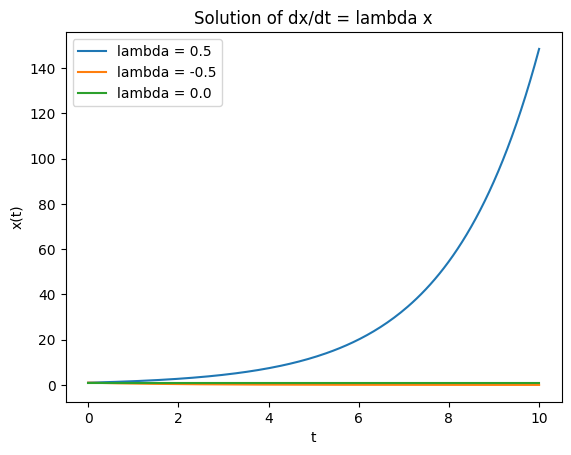

In [2]:
x0 = 1.0
t = jnp.linspace(0, 10, 200)

for lam in [0.5, -0.5, 0.0]:
    x = x0 * jnp.exp(lam * t)
    plt.plot(t, x, label=f"lambda = {lam}")

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Solution of dx/dt = lambda x")
plt.legend()
plt.show()

#  Exercise 2: Numerical approximation for the harmonic oscillator (7 points)

Not all systems can be solved analytically. For these systems, we can instead use numerical techniques to solve the integration in order to get the system's trajectory. You may implement the simulation using a for-loop or with jax.lax.scan() (which we advice).

### 2.1:

First we will visualize the analytical solution of the harmonic oscillator. The analytical solution of the harmonic oscillator is given by:

$$x(t) = cos(t)$$

$$v(t) = -sin(t)$$

Show the solution over the time range $t \in [0, 50]$

## 2.1 Solution:

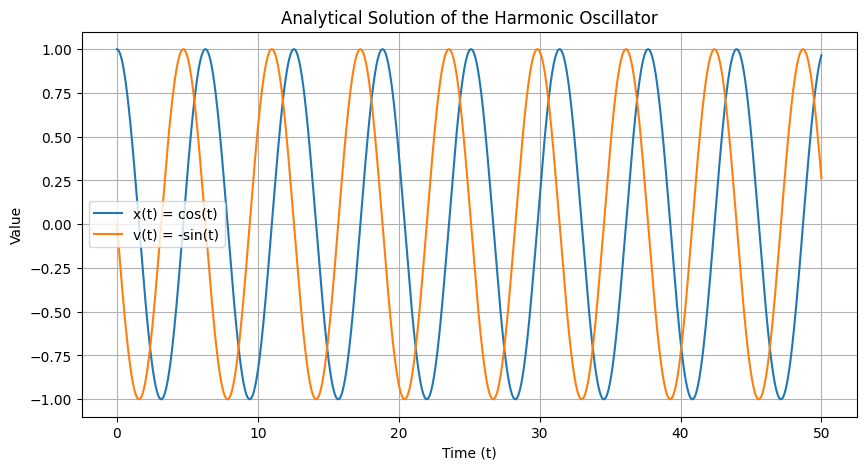

In [13]:
# Time range
t = jnp.linspace(0, 50, 5000)

# Analytical solution
x = jnp.cos(t)
v = -jnp.sin(t)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(t, x, label="x(t) = cos(t)")
plt.plot(t, v, label="v(t) = -sin(t)")

plt.xlabel("Time (t)")
plt.ylabel("Value")
plt.title("Analytical Solution of the Harmonic Oscillator")
plt.legend()
plt.grid(True)

plt.show()

## 2.2:
Create a numerical approximation of the simple harmonic oscillator (i.e., the harmonic oscillator with a damping coefficient of zero) using the Euler method: $$  x_{n+1}=x_{n}+\Delta_t f(t_{n},x_{n}) $$

Solve the system forward in the range $t \in [0, 50]$ using varying step sizes, given some (non-zero) initial condition. Also show the analytical solution.

Comment on what you see, and explain your observations.

## Solution 2.2:

In [15]:
def simple_harmonic_oscillator(X, k):
    """
    Simple harmonic oscillator model

    X: state vector [x, xdot]
    k: spring constant
    """
    x, xdot = X[0], X[1]

    return jnp.array([xdot, -k * x])

In [17]:
def euler(f, x, t, dt):
    """
    Euler approximation

    f: state equation function
    t: time at which the function is evaluated
    x: state vector at time k
    dt: step size

    Returns the state at time k+1
    """

    return x + dt * f(x, t)

In [18]:
# General Euler function
def get_euler(f, dt):
    def euler_scan_fn(carry, t):
      next_state = euler(f, carry, t, dt)

      return next_state, next_state

    return euler_scan_fn

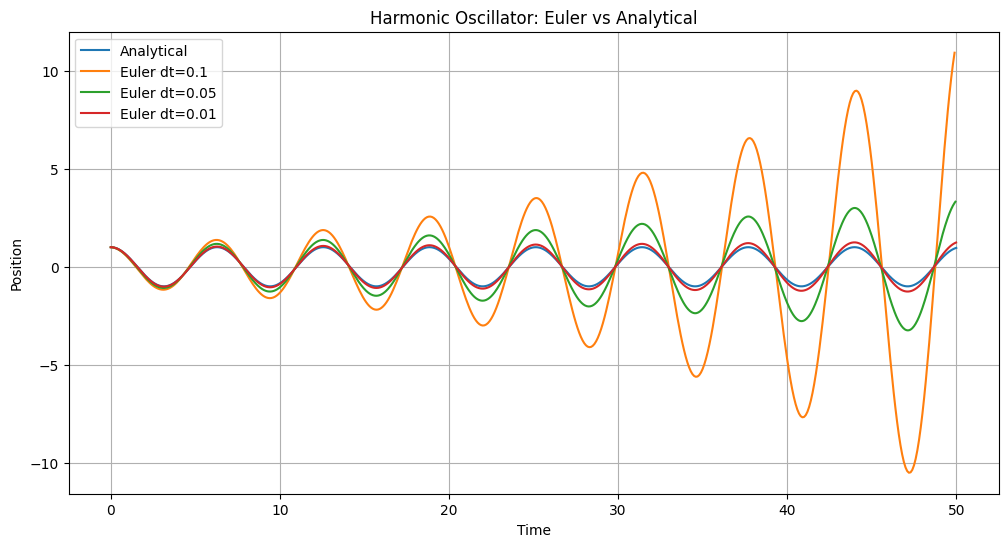

In [20]:
def simple_harmonic_oscillator(X, k):
    x, xdot = X
    return jnp.array([xdot, -k * x])

def euler_step(f, dt):
    def step(x, t):
        x_next = x + dt * f(x, t)
        return x_next, x_next
    return step

k = 1.0
init_state = jnp.array([1.0, 0.0])
t_max = 50.0

f_sho = lambda X, t: simple_harmonic_oscillator(X, k)

# Analytical
t_fine = jnp.linspace(0, t_max, 5000)
x_analytical = jnp.cos(t_fine)

plt.figure(figsize=(12, 6))
plt.plot(t_fine, x_analytical, label="Analytical")

# Euler + lax.scan
for dt in [0.1, 0.05, 0.01]:
    t = jnp.arange(0, t_max, dt)
    _, trajectory = jax.lax.scan(
        euler_step(f_sho, dt),
        init_state,
        t
    )
    plt.plot(t, trajectory[:, 0], label=f"Euler dt={dt}")

plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Harmonic Oscillator: Euler vs Analytical")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# 1. OBSERVATIONS:
# Analytical solution cos(t) has constant amplitude and energy.
# Euler causes artificial energy growth and amplitude divergence.
# Larger dt diverges faster; smaller dt reduces the error.
#
# 2. MATHEMATICAL EXPLANATION:
# Euler has global error O(dt).
# det(M) = 1 + k*dt^2 > 1, causing artificial energy growth.

## 2.3

Write a RK4 solver and use it to simulate the simple harmonic oscillator. Using different step sizes, what do you observe? Compare your solution with Euler’s method. The RK4 solvers works as follows:

$$x_{n+1} = x_n + \frac{\Delta_t}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$
$$t_{n+1} = t_n + \Delta_t$$
with
$$k_1 = f(t_n, x_n)$$
$$k_2 = f(t_n + \frac{\Delta_t}{2}, x_n + \Delta_t\frac{k_1}{2})$$
$$k_3 = f(t_n + \frac{\Delta_t}{2}, x_n + \Delta_t\frac{k_2}{2})$$
$$k_4 = f(t_n + \Delta_t, x_n + \Delta_t k_3)$$

## Solution 2.3

In [21]:
# General RK4 function
def get_rk4(f, dt):
    def rk4_scan_fn(carry, t):
        k1 = f(carry, t)
        k2 = f(carry + dt*k1/2, t + dt/2)
        k3 = f(carry + dt*k2/2, t + dt/2)
        k4 = f(carry + dt*k3, t + dt)

        next_state = carry + dt*(k1 + 2*k2 + 2*k3 + k4)/6

        return next_state, next_state

    return rk4_scan_fn

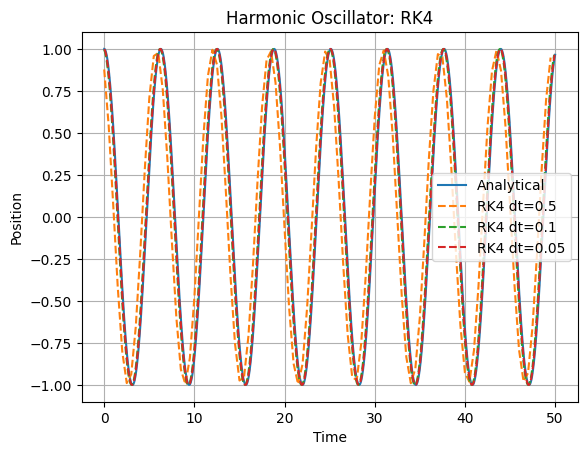

In [22]:
#Visualize the harmonic oscillator integrated with RK4 for different step sizes
init_state = jnp.array([1.0, 0.0])
t_max = 50.0

f_sho = lambda X, t: simple_harmonic_oscillator(X, 1.0)

# Analytical solution
t_fine = jnp.linspace(0, t_max, 5000)
plt.plot(t_fine, jnp.cos(t_fine), label="Analytical")

# RK4 with lax.scan
for dt in [0.5, 0.1, 0.05]:
    t = jnp.arange(0, t_max, dt)

    _, trajectory = jax.lax.scan(
        get_rk4(f_sho, dt),
        init_state,
        t
    )

    plt.plot(t, trajectory[:, 0], "--", label=f"RK4 dt={dt}")

plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Harmonic Oscillator: RK4")
plt.legend()
plt.grid()
plt.show()

In [24]:
# what do you observe?
# High Accuracy: RK4 closely matches the analytical solution, even with larger step sizes. Smaller \(\Delta t\) further reduces the error.
# Better Stability: Forward Euler shows artificial energy growth and gradually moves away from the true solution. RK4 remains much more stable.
# Accuracy vs. Cost: RK4 uses 4 function evaluations per step but has 4th-order accuracy, \(O(\Delta t^4)\), compared with Euler's \(O(\Delta t)\).
#RK4 is more accurate and stable than Forward Euler, but requires 4 function evaluations per step instead of 1.